# core

> Fill in a module description here

In [ ]:
#| default_exp ejemplo

In [ ]:
#| hide
from nbdev.showdoc import *


In [ ]:
#| hide
#| export
from nbdev.showdoc import *
import matplotlib
import sklearn
import random
import numpy as np
import shapely
from sklearn.cluster import DBSCAN, HDBSCAN, OPTICS, KMeans
import matplotlib.pyplot as plt

In [ ]:
#| export
class data_points:
    """Una clase que contiene a los datos"""
    def __init__(self, n, min_x=0, min_y=0, max_x=1, max_y=1, seed=None):
        if seed is not None:
            random.seed(seed)
        
        Xpoint = np.random.uniform(low=min_x, high=max_x, size=n)
        Ypoint = np.random.uniform(low=min_y, high=max_y, size=n)
        
        self.Points = [shapely.Point(x[0], x[1]) for x in zip(Xpoint, Ypoint)]
    
    @classmethod
    def from_list(cls, list_points):
        """Se genera los datos usando una lista de puntos"""
        toto = cls(0)
        toto.Points = list_points
        return toto
    
    def get_points(self):
        """Una funcion que para obtener los puntos"""
        return self.Points
        
    def get_Multypoint(self):
        """Regresa un objeto MultiPoint con los puntos"""
        return shapely.geometry.MultiPoint(self.Points)
    
    def get_X(self):
        """Regresa las coordenadas X"""
        return [x.x for x in self.Points]

    def get_Y(self):
        """Regresa las coordenadas X"""
        return [x.y for x in self.Points]
    
    def centroid(self):
        """Regresa el centroide de los puntos """
        return shapely.centroid(self.get_Multypoint())
    
    def as_array(self):
        """Regresa los puntos como un array"""
        list_arrays = np.array([(geom.xy[0][0], geom.xy[1][0]) for geom in self.Points])
        return list_arrays
    
    def add_points(self, data_points):
        """Agrega puntos de otra """
        self.Points = self.Points + data_points.Points
        return

In [ ]:
#| hide
datos_simples = data_points(40)
datos_simples.get_points()
datos_simples.get_points()
datos_simples.get_Multypoint()
datos_simples.get_X()
if len(datos_simples.get_X()) != len(datos_simples.get_Y()):
    raise Exception("Si hay problema la evaluacion ")

In [ ]:
#| export

class Clusters:
    """Una clase que contiene los clusters"""
    def __init__(self, data_structure):
        self.data_structure = data_structure
    
    def DBSCAN(self, eps=0.3, min_samples=5):
        """Realiza un DBSCAN clustering"""
        clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(self.data_structure.as_array())
        self.data_structure.classes_DBSCAN = clustering.labels_
        return clustering
    
    def KMeans(self, n_clusters=4):
        """Realiza un KMeans clustering"""
        clustering = KMeans(n_clusters=n_clusters).fit(self.data_structure.as_array())
        self.data_structure.classes_Kmeans = clustering.labels_
        return clustering
    
    def HDBSCAN(self, min_cluster_size=5):
        """Realiza un HDBSCAN clustering"""
        clustering = HDBSCAN(min_cluster_size=min_cluster_size).fit(self.
        data_structure.as_array())
        self.data_structure.classes_HDBSCAN = clustering.labels_
        return clustering

    def OPTICS(self, min_samples=5):
        """Realiza un OPTICS clustering"""
        clustering = OPTICS(min_samples=min_samples).fit(self.data_structure.as_array())
        self.data_structure.classes_OPTICS = clustering.labels_
        return clustering

In [ ]:
#| hide
datos_simples = data_points(40)

cluster_all = Clusters(datos_simples)
cluster_all.DBSCAN()
cluster_all.KMeans()
cluster_all.HDBSCAN()
cluster_all.OPTICS()

C:\Users\msalazar\miniconda3_bi\envs\prueba\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
C:\Users\msalazar\miniconda3_bi\envs\prueba\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\msalazar\miniconda3_bi\envs\prueba\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy`

,"min_samples min_samples: int > 1 or float between 0 and 1, default=5The number of samples in a neighborhood for a point to be considered asa core point. Also, up and down steep regions can't have more than``min_samples`` consecutive non-steep points. Expressed as an absolutenumber or a fraction of the number of samples (rounded to be at least2).",5
,"max_eps max_eps: float, default=np.infThe maximum distance between two samples for one to be considered asin the neighborhood of the other. Default value of ``np.inf`` willidentify clusters across all scales; reducing ``max_eps`` will resultin shorter run times.",inf
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Any metric from scikit-learnor :mod:`scipy.spatial.distance` can be used.If `metric` is a callable function, it is called on eachpair of instances (rows) and the resulting value recorded. The callableshould take two arrays as input and return one value indicating thedistance between them. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string. If metric is""precomputed"", `X` is assumed to be a distance matrix and must besquare.Valid values for metric are:- from scikit-learn: ['cityblock', 'cosine', 'euclidean', 'l1', 'l2', 'manhattan']- from scipy.spatial.distance: ['braycurtis', 'canberra', 'chebyshev', 'correlation', 'dice', 'hamming', 'jaccard', 'kulsinski', 'mahalanobis', 'minkowski', 'rogerstanimoto', 'russellrao', 'seuclidean', 'sokalmichener', 'sokalsneath', 'sqeuclidean', 'yule']Sparse matrices are only supported by scikit-learn metrics.See :mod:`scipy.spatial.distance` for details on these metrics... note:: `'kulsinski'` is deprecated from SciPy 1.9 and will be removed in SciPy 1.11.",'minkowski'
,"p p: float, default=2Parameter for the Minkowski metric from:class:`~sklearn.metrics.pairwise_distances`. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"cluster_method cluster_method: {'xi', 'dbscan'}, default='xi'The extraction method used to extract clusters using the calculatedreachability and ordering.",'xi'
,"eps eps: float, default=NoneThe maximum distance between two samples for one to be considered asin the neighborhood of the other. By default it assumes the same valueas ``max_eps``.Used only when ``cluster_method='dbscan'``.",None
,"xi xi: float between 0 and 1, default=0.05Determines the minimum steepness on the reachability plot thatconstitutes a cluster boundary. For example, an upwards point in thereachability plot is defined by the ratio from one point to itssuccessor being at most 1-xi.Used only when ``cluster_method='xi'``.",0.05
,"predecessor_correction predecessor_correction: bool, default=TrueCorrect clusters according to the predecessors calculated by OPTICS[2]_. This parameter has minimal effect on most datasets.Used only when ``cluster_method='xi'``.",True
,"min_cluster_size min_cluster_size: int > 1 or float between 0 and 1, default=NoneMinimum number of samples in an OPTICS cluster, expressed as anabsolute number or a fraction of the number of samples (rounded to beat least 2). If ``None``, the value of ``min_samples`` is used instead.Used only when ``cluster_method='xi'``.",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`~sklearn.neighbors.BallTree`.- 'kd_tree' will use :class:`~sklearn.neighbors.KDTree`.- 'brute' will use a brute-force search.- 'auto' (default) will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'


In [ ]:
show_doc(Clusters.KMeans)

---

### Clusters.KMeans

```python

def KMeans(
    n_clusters:int=4
):


```

*Realiza un KMeans clustering*

In [ ]:
show_doc(Clusters.DBSCAN)

---

### Clusters.DBSCAN

```python

def DBSCAN(
    eps:float=0.3, min_samples:int=5
):


```

*Realiza un DBSCAN clustering*

In [ ]:
show_doc(Clusters.HDBSCAN)

---

### Clusters.HDBSCAN

```python

def HDBSCAN(
    min_cluster_size:int=5
):


```

*Realiza un HDBSCAN clustering*

In [ ]:
show_doc(Clusters.OPTICS)

---

### Clusters.OPTICS

```python

def OPTICS(
    min_samples:int=5
):


```

*Realiza un OPTICS clustering*

In [ ]:
datos_simples_3 = data_points(500, min_x=0.6, min_y=0.6, max_x=1.0, max_y =1.0)
datos_simples_2 = data_points(500, min_x=0.0, min_y=0.6, max_x=0.4, max_y =1.0)
datos_simples_1 = data_points(500, min_x=0.6, min_y=0.0, max_x=1.0, max_y =0.4)
datos_simples_0 = data_points(500, min_x=0.0, min_y=0.0, max_x=0.4, max_y =0.4)

In [ ]:
datos_simples_0.add_points(datos_simples_1)
datos_simples_0.add_points(datos_simples_2)
datos_simples_0.add_points(datos_simples_3)

In [ ]:
datos_simples_0.get_Multypoint()
cluster_all = Clusters(datos_simples_0)
cluster_all.OPTICS()
cluster_all.HDBSCAN()
cluster_all.DBSCAN(eps=0.1, min_samples=10)
cluster_all.KMeans()

C:\Users\msalazar\miniconda3_bi\envs\prueba\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
C:\Users\msalazar\miniconda3_bi\envs\prueba\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


<matplotlib.collections.PathCollection>

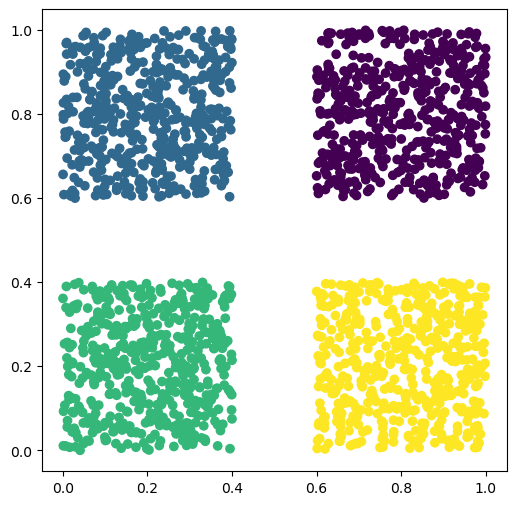

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
plt.scatter(
cluster_all.data_structure.get_X(),
cluster_all.data_structure.get_Y(),
c=cluster_all.data_structure.classes_Kmeans
)

<matplotlib.collections.PathCollection>

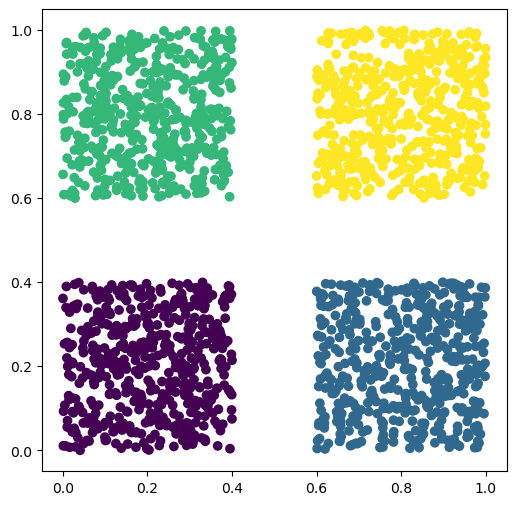

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
plt.scatter(
cluster_all.data_structure.get_X(),
cluster_all.data_structure.get_Y(),
c=cluster_all.data_structure.classes_DBSCAN
)

<matplotlib.collections.PathCollection>

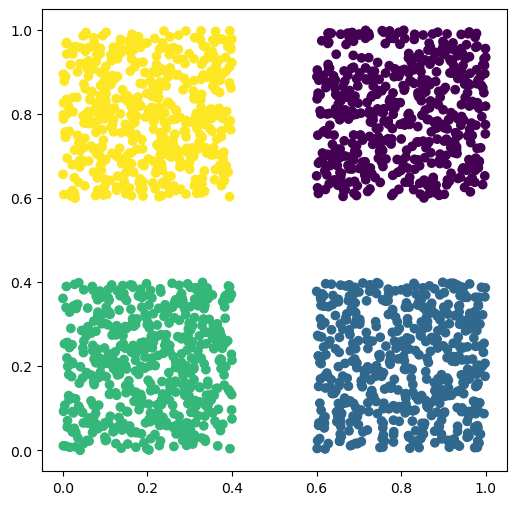

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
plt.scatter(
cluster_all.data_structure.get_X(),
cluster_all.data_structure.get_Y(),

c=cluster_all.data_structure.classes_HDBSCAN
)

<matplotlib.collections.PathCollection>

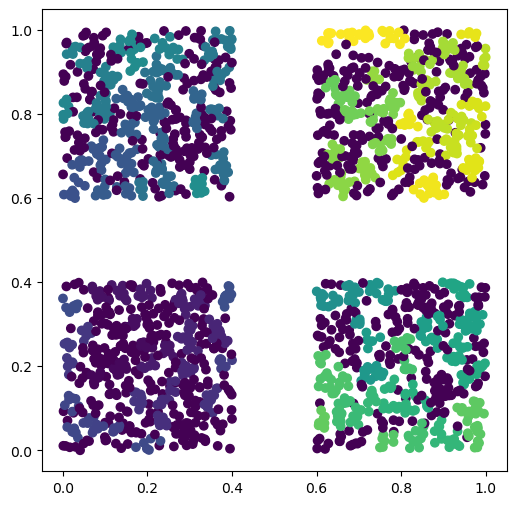

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
plt.scatter(
cluster_all.data_structure.get_X(),
cluster_all.data_structure.get_Y(),
c=cluster_all.data_structure.classes_OPTICS
)

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()